# Phase 2: ordered SPC and capability
Synthetic production. Fixed seed20260914; no seed searching or alarm removal. See README.md for sampling, formulas and references.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root=Path.cwd()
m=json.loads((root/'results.json').read_text())
d=pd.read_csv(root/'spc_data.csv')
g=pd.read_csv(root/'subgroup_results.csv',keep_default_na=False)
display(d.groupby('Phase',sort=False).agg(Parts=('Part_ID','size'),Failures=('Diameter_Fail','sum')))

,Parts,Failures
Phase,,
reference,200,0
setup_shift,100,22
rebaseline,200,0
verification,200,0


## Frozen-limit monitoring
Estimate groups1-40; evaluate41-60 with the same limits. Re-estimate only from61-100, then hold fixed for101-140. The selected-rule alert in verification is retained.

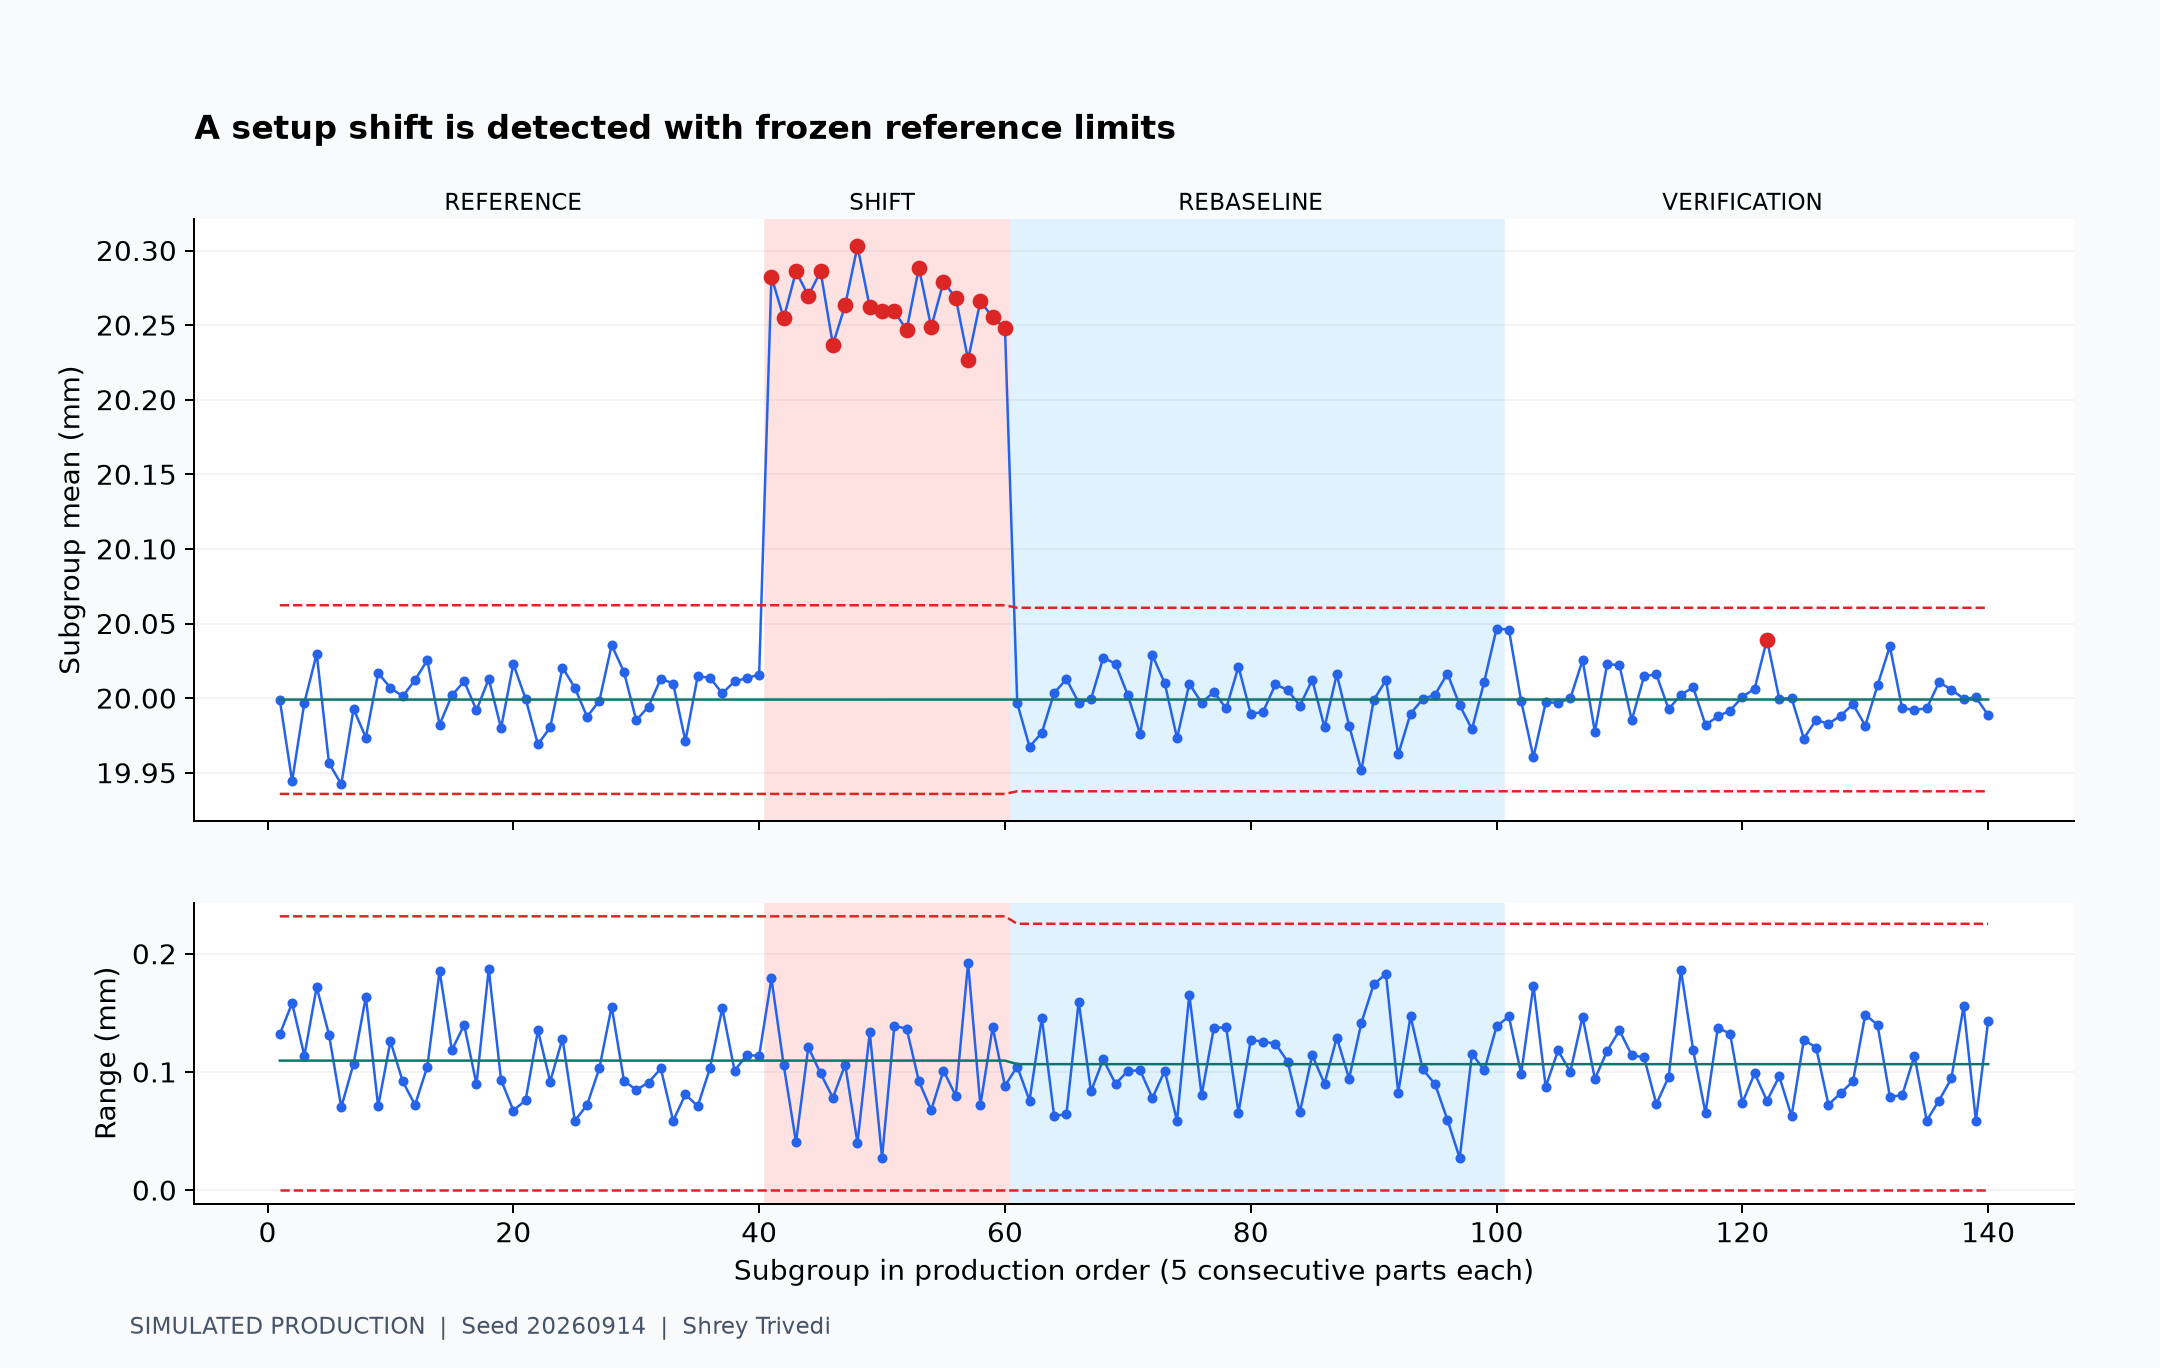

,Subgroup,Phase,Mean,Range,X_Rules,R_Rules
40,41,setup_shift,20.282412,0.179117,T1,
41,42,setup_shift,20.254688,0.105600,T1,
42,43,setup_shift,20.286034,0.040640,"T1,T2",
43,44,setup_shift,20.269643,0.120952,"T1,T2",
44,45,setup_shift,20.285961,0.098719,"T1,T2",
45,46,setup_shift,20.236941,0.078172,"T1,T2",
46,47,setup_shift,20.263301,0.106310,"T1,T2",
47,48,setup_shift,20.302845,0.040007,"T1,T2",
48,49,setup_shift,20.262207,0.133453,"T1,T2",
49,50,setup_shift,20.259147,0.027372,"T1,T2",


In [2]:
display(Image(filename='charts/01_xbar_r.png'))
display(g[(g.X_Rules!='')|(g.R_Rules!='')][['Subgroup','Phase','Mean','Range','X_Rules','R_Rules']])

## Capability: conditional interpretation
Reference and rebaseline have no selected-rule signals. Verification is provisional because of T3. Shifted and pooled results are descriptive and cannot establish stable capability.

,n,mean,within_sd,overall_sd,Cp,Cpk,Pp,Ppk,failures,interpretation
reference,200,19.999045,0.047122,0.047009,2.122171,2.115415,2.127274,2.120502,0,no selected-rule signals in finite window
setup_shift,100,20.264467,0.043792,0.044151,2.283547,0.270474,2.264929,0.268269,22,unstable against reference; descriptive indice...
rebaseline,200,19.999089,0.045838,0.044915,2.181586,2.174963,2.226429,2.219669,0,no selected-rule signals in finite window
verification,200,20.000156,0.046242,0.043718,2.162555,2.16143,2.287365,2.286175,0,provisional: selected-rule signal requires review
pooled_invalid,700,20.037292,0.046028,0.103138,2.172602,1.90253,0.96957,0.849045,22,mixed regimes; not a capability claim


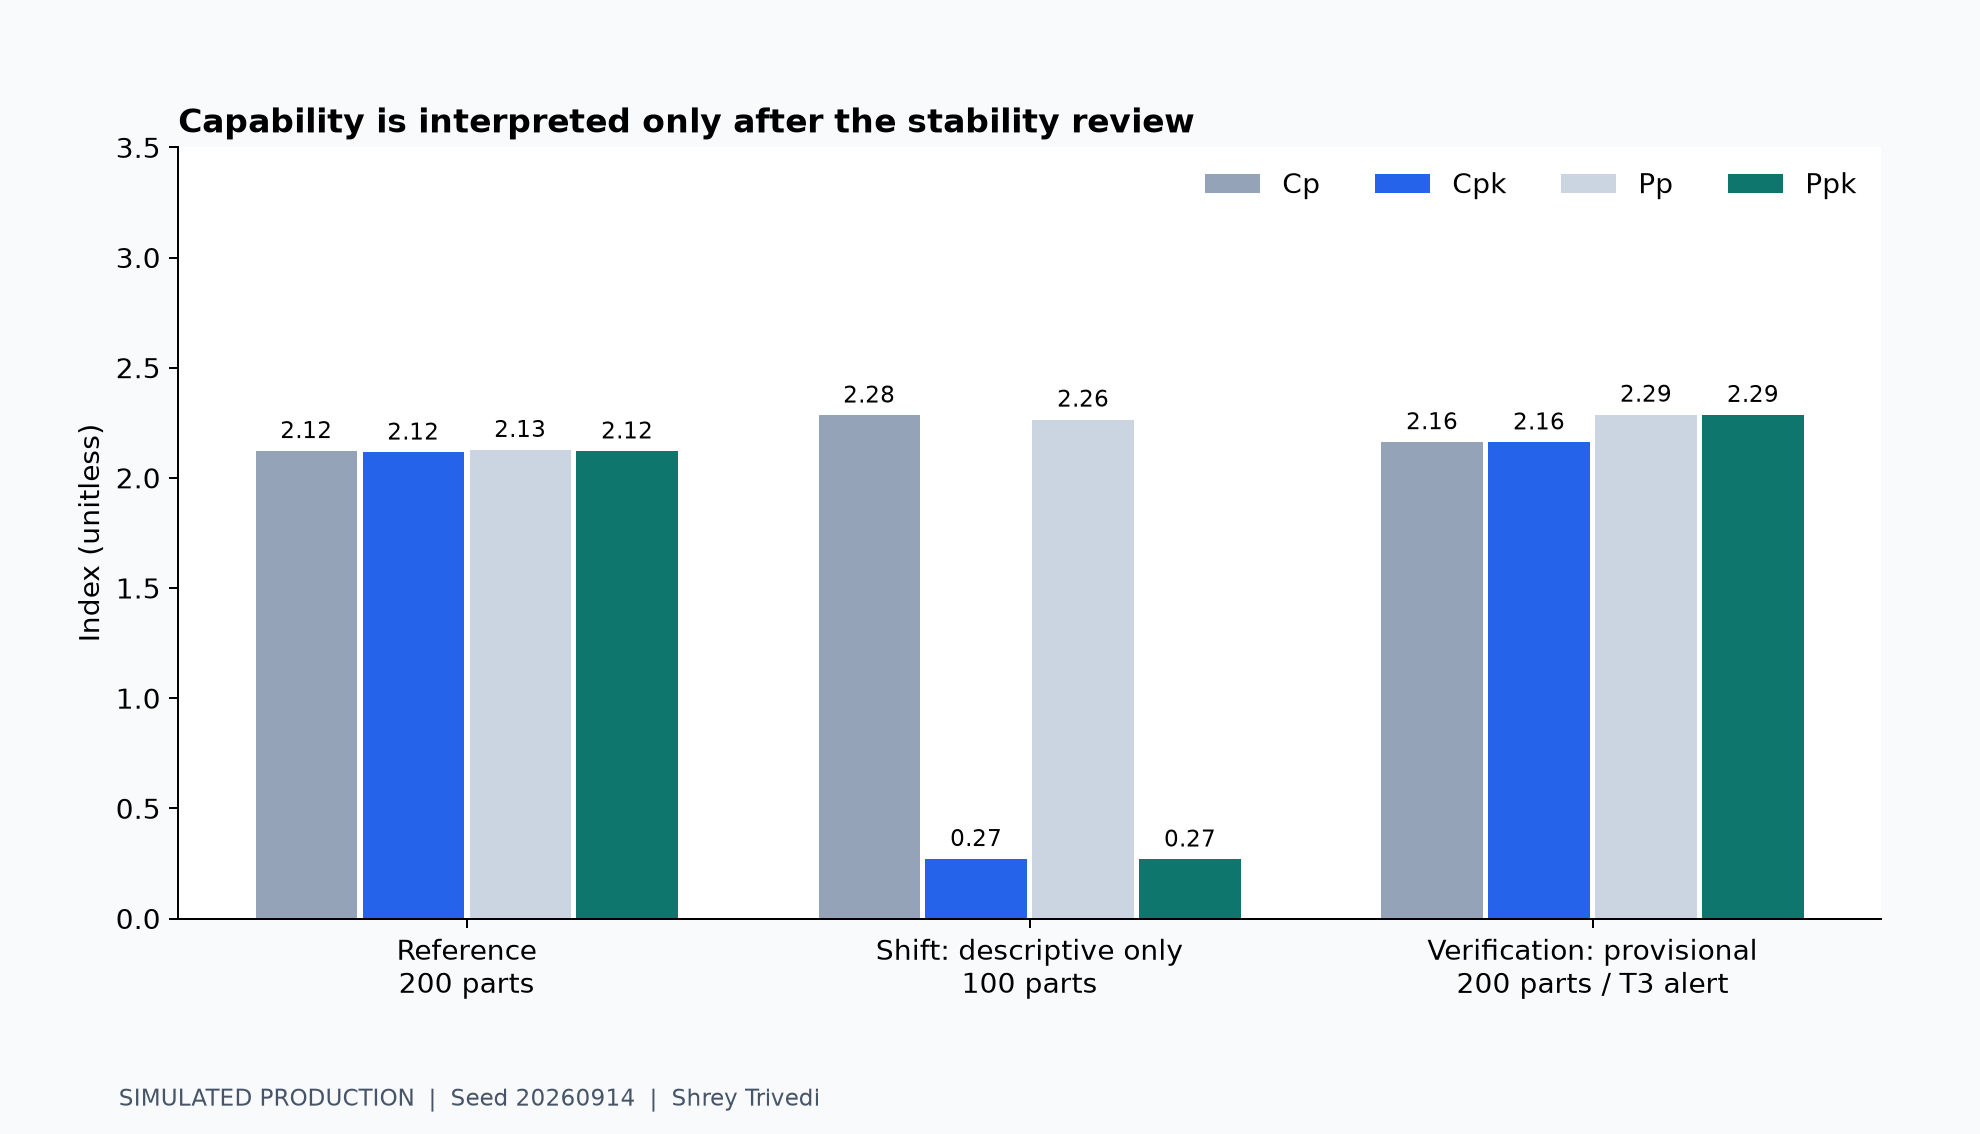

In [3]:
display(pd.DataFrame(m['capability']).T[['n','mean','within_sd','overall_sd','Cp','Cpk','Pp','Ppk','failures','interpretation']])
display(Image(filename='charts/04_capability.png'))

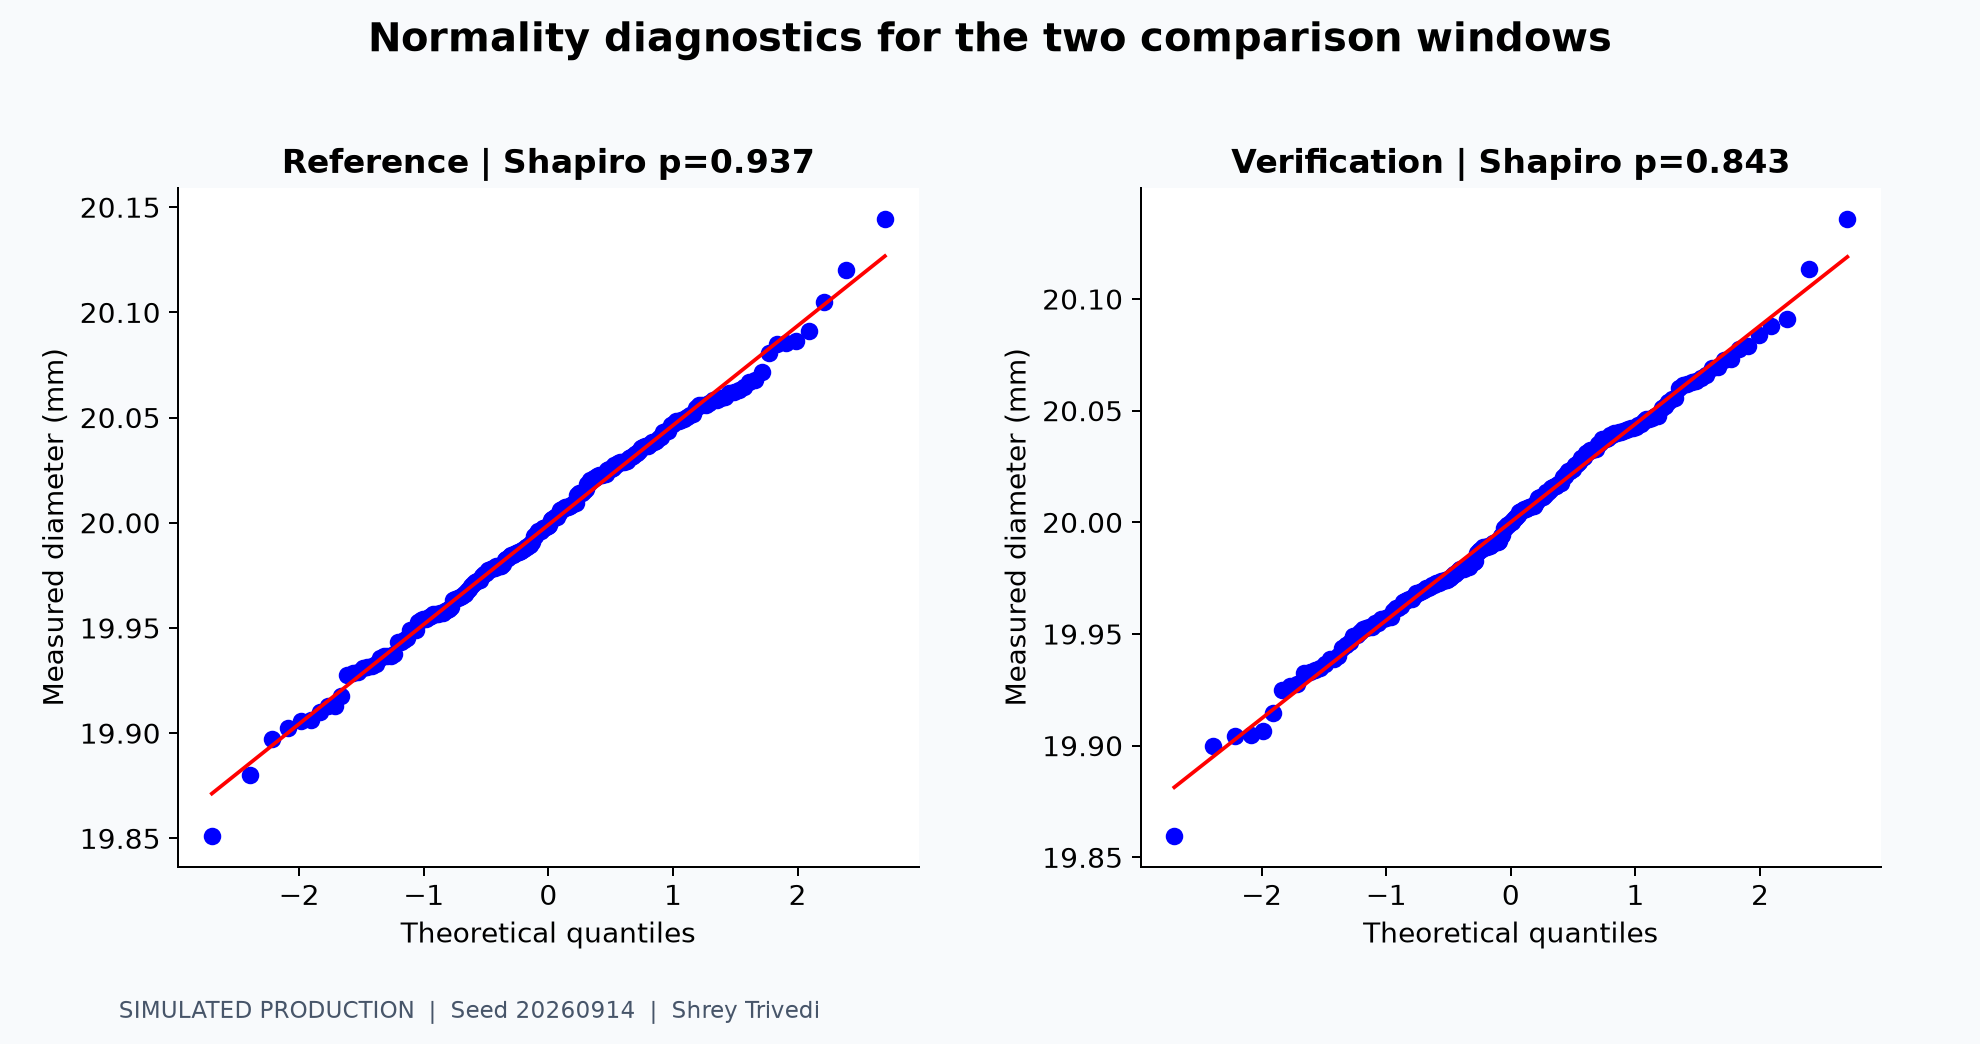

,shapiro_p,lag1,zero_failure_upper95
reference,0.936529,-0.075833,0.014867
setup_shift,0.655731,-0.156452,None
rebaseline,0.971788,-0.066158,0.014867
verification,0.842721,-0.067867,0.014867
pooled_invalid,0.0,0.780193,None


In [4]:
display(Image(filename='charts/03_normality.png'))
display(pd.DataFrame(m['capability']).T[['shapiro_p','lag1','zero_failure_upper95']])

## Corrective-action decision
The programmed shift produces22/100 rejects. Verification produces0/200 but a trend alarm, so effectiveness review remains open. Consult ../quality_documents/corrective_action.md and ../drawing_and_inspection/inspection_plan.md for linked actions and separate simulated inspection examples. Minitab runs remain pending authenticated access.